In [56]:
!nvidia-smi

Mon Jun  8 11:44:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.91                 Driver Version: 591.91         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   36C    P8              3W /   85W |      18MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [57]:
import torch

def check_cuda():
    print("=== PyTorch CUDA Diagnostic ===\n")

    # 1. Is CUDA available?
    cuda_available = torch.cuda.is_available()
    print(f"CUDA available: {cuda_available}")

    # 2. PyTorch build info
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA version (torch): {torch.version.cuda}")

    if not cuda_available:
        print("\n[FAIL] CUDA is not available.")
        return

    # 3. GPU details
    device_count = torch.cuda.device_count()
    print(f"\nNumber of GPUs: {device_count}")

    for i in range(device_count):
        print(f"\n--- GPU {i} ---")
        print(f"Name: {torch.cuda.get_device_name(i)}")
        print(f"Capability: {torch.cuda.get_device_capability(i)}")
        print(f"Memory Allocated: {torch.cuda.memory_allocated(i)} bytes")
        print(f"Memory Reserved: {torch.cuda.memory_reserved(i)} bytes")

    # 4. Actual computation test (this is the only *real* proof)
    try:
        device = torch.device("cuda:0")
        x = torch.rand(3, 3).to(device)
        y = torch.rand(3, 3).to(device)
        z = x @ y

        print("\n[OK] Tensor computation on GPU succeeded.")
        print(f"Result device: {z.device}")

    except Exception as e:
        print("\n[FAIL] CUDA exists but computation failed.")
        print(f"Error: {e}")


if __name__ == "__main__":
    check_cuda()

=== PyTorch CUDA Diagnostic ===

CUDA available: True
PyTorch version: 2.12.0.dev20260324+cu128
CUDA version (torch): 12.8

Number of GPUs: 1

--- GPU 0 ---
Name: NVIDIA GeForce RTX 5060 Laptop GPU
Capability: (12, 0)
Memory Allocated: 125355008 bytes
Memory Reserved: 461373440 bytes

[OK] Tensor computation on GPU succeeded.
Result device: cuda:0


## Dataset Unzip

In [58]:
from pathlib import Path
import zipfile

# Paths
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "0_Datasets"

DATASET_PATH_ZIP = DATA_DIR / "Mosquitoes_dataset.zip"
EXTRACT_DIR = DATA_DIR / "Mosquitoes_dataset"

In [59]:
# Unzip
with zipfile.ZipFile(DATASET_PATH_ZIP, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)

Extracted to: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset


## Dataset inspection

In [60]:
from pathlib import Path

# Path
ROOT = Path.cwd().parent

DATASET_PATH = ROOT / "0_Datasets" / "Mosquitoes_dataset"

In [61]:
import os
os.listdir(DATASET_PATH)

['data.yaml',
 'README.dataset.txt',
 'README.roboflow.txt',
 'test',
 'train',
 'valid']

In [62]:
DATASET_PATH_YAML = ROOT / "0_Datasets" / "Mosquitoes_dataset" / "data.yaml"

with open(DATASET_PATH_YAML, 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['0']

roboflow:
  workspace: mosquitos-4tgsz
  project: mos_and_nonmos-2
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/mosquitos-4tgsz/mos_and_nonmos-2/dataset/1


In [63]:
import os
from collections import defaultdict

def analizar_dataset_yolo_roboflow(dataset_path):
    splits = ['train', 'valid', 'test']
    ext_img = ('.jpg', '.jpeg', '.png')

    total_imgs = 0
    split_counts = {}
    class_counts = defaultdict(int)
    all_classes = set()

    print(f"\n Analyzing dataset in: {dataset_path}\n")

    for split in splits:
        images_dir = os.path.join(dataset_path, split, "images")
        labels_dir = os.path.join(dataset_path, split, "labels")

        if not os.path.exists(images_dir):
            print(f" No se encontró la carpeta {images_dir}")
            continue

        images = [f for f in os.listdir(images_dir) if f.lower().endswith(ext_img)]
        split_counts[split] = len(images)
        total_imgs += len(images)

        for img in images:
            base_name = os.path.splitext(img)[0]
            label_file = base_name + '.txt'
            label_path = os.path.join(labels_dir, label_file)
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                    for line in lines:
                        cls_id = line.strip().split()[0]
                        class_counts[cls_id] += 1
                        all_classes.add(cls_id)

    print(" Dataset Statistics:")
    print(f"   - Total images: {total_imgs}")
    for split in splits:
        count = split_counts.get(split, 0)
        pct = (count / total_imgs * 100) if total_imgs > 0 else 0
        print(f"   - {split.capitalize():<6}: {count} images ({pct:.2f}%)")

    print("\n Classes found:")
    if all_classes:
        sorted_classes = sorted(all_classes, key=lambda x: int(x))
        for cls_id in sorted_classes:
            print(f"   - Class {cls_id}: {class_counts[cls_id]} images")
    else:
        print("   - No se encontraron clases (verifica los archivos .txt)")

analizar_dataset_yolo_roboflow(DATASET_PATH)


 Analyzing dataset in: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset

 Dataset Statistics:
   - Total images: 22309
   - Train : 19530 images (87.54%)
   - Valid : 1400 images (6.28%)
   - Test  : 1379 images (6.18%)

 Classes found:
   - Class 0: 17140 images


## Inspection of the hyperparameter search

In [64]:
import optuna

STUDY_NAME="yolo_search"

In [65]:
study = optuna.load_study(
    study_name= STUDY_NAME,  
    storage="sqlite:///optuna.db"
)

print("Best trial:")
print(study.best_trial)

Best trial:
FrozenTrial(number=47, state=<TrialState.COMPLETE: 1>, values=[0.9632916441628662], datetime_start=datetime.datetime(2026, 3, 29, 1, 18, 55, 898323), datetime_complete=datetime.datetime(2026, 3, 29, 1, 39, 56, 491564), params={'lr0': 0.048117056448515556, 'lrf': 0.10572865615957065, 'momentum': 0.805892487977318, 'weight_decay': 8.671311282524392e-05, 'warmup_epochs': 1.7207575123688748, 'box': 0.07140798031378946, 'cls': 0.46312589434355633, 'dfl': 1.3127070468937196, 'hsv_h': 0.017351360216514393, 'hsv_s': 0.6971630715901096, 'hsv_v': 0.3213744936509859, 'flipud': 0.2882519808308238, 'fliplr': 0.5636196176412798, 'mosaic': 0.5937355916148969, 'mixup': 0.09972237348000992}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'lr0': FloatDistribution(high=0.05, log=True, low=0.0001, step=None), 'lrf': FloatDistribution(high=0.5, log=False, low=0.05, step=None), 'momentum': FloatDistribution(high=0.98, log=False, low=0.7, step=None), 'weight_decay': FloatD

In [66]:
best = study.best_trial

print("Best value:", best.value)
print("Best params:")
for k, v in best.params.items():
    print(f"{k}: {v}")

Best value: 0.9632916441628662
Best params:
lr0: 0.048117056448515556
lrf: 0.10572865615957065
momentum: 0.805892487977318
weight_decay: 8.671311282524392e-05
warmup_epochs: 1.7207575123688748
box: 0.07140798031378946
cls: 0.46312589434355633
dfl: 1.3127070468937196
hsv_h: 0.017351360216514393
hsv_s: 0.6971630715901096
hsv_v: 0.3213744936509859
flipud: 0.2882519808308238
fliplr: 0.5636196176412798
mosaic: 0.5937355916148969
mixup: 0.09972237348000992


In [67]:
import os
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate
)

# ==============================
# Create output directory
# ==============================
SAVE_DIR = "hyper_search_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

# ==============================
# Generate figures
# ==============================
fig1 = plot_optimization_history(study)
fig2 = plot_param_importances(study)
fig3 = plot_parallel_coordinate(study)

# ==============================
# Save figures
# ==============================
fig1_path = os.path.join(SAVE_DIR, "opt_history.png")
fig2_path = os.path.join(SAVE_DIR, "param_importance.png")
fig3_path = os.path.join(SAVE_DIR, "parallel_coords.png")

fig1.write_image(fig1_path)
fig2.write_image(fig2_path)
fig3.write_image(fig3_path)

# ==============================
# Show figures in notebook
# ==============================
fig1.show()
fig2.show()
fig3.show()

print(f"Plots saved in: {SAVE_DIR}")

Plots saved in: hyper_search_plots


## Inspection of the YOLO PyTorch model

In [68]:
import ultralytics
from ultralytics import YOLO
ultralytics.checks()

Ultralytics 8.4.26  Python-3.12.10 torch-2.12.0.dev20260324+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Setup complete  (24 CPUs, 31.6 GB RAM, 769.8/924.4 GB disk)


In [75]:
from pathlib import Path

# Path
ROOT = Path.cwd().parent

YOLO_MODEL_PATH = ROOT / "Models" / "best.pt"

model = YOLO(YOLO_MODEL_PATH)

print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
  

In [76]:
import torch

ROOT = Path.cwd().parent

YOLO_MODEL_PATH = ROOT / "Models" / "best.pt"

model = YOLO(YOLO_MODEL_PATH)

x = torch.randn(1, 3, 256, 256)
y = model.model(x)

print(y[0].shape)

torch.Size([1, 5, 1344])


In [77]:
from pathlib import Path

# Path
ROOT = Path.cwd().parent

DATASET_PATH_YAML = ROOT / "0_Datasets"/ "Mosquitoes_dataset" / "data.yaml"

metrics = model.val(
    data=DATASET_PATH_YAML,
    split="test",
    imgsz=256,
    conf=0.001,
    iou=0.6,
    save_json=True,
    plots=True
)

print(metrics)

Ultralytics 8.4.26  Python-3.12.10 torch-2.12.0.dev20260324+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 257.0114.8 MB/s, size: 23.5 KB)
val: Scanning C:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\test\labels.cache... 1379 images, 492 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1379/1379  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 87/87 18.9it/s 4.6s0.0s
                   all       1379       1000      0.967       0.96      0.975      0.744
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving C:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\1_YOLO\runs\detect\val\predictions.json...
Results saved to C:\Users\lucas\Desktop\Trabajo Fi

In [79]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

mAP50: 0.974600149173569
mAP50-95: 0.7435593784128061
Precision: 0.9671746211009693
Recall: 0.96


In [80]:
# Path
ROOT = Path.cwd().parent
DATASET_PATH_TEST_IMAGES = ROOT / "0_Datasets"/ "Mosquitoes_dataset" / "test" / "images"

results = model.predict(DATASET_PATH_TEST_IMAGES, save=False)

counts = [len(r.boxes) for r in results]

import numpy as np
print("Mean detections:", np.mean(counts))
print("Std detections:", np.std(counts))


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1379 c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\test\images\-701466_jpeg_jpg.rf.0b1816500997ace82e538073efeace31.jpg: 256x256 (no detections), 13.1ms
image 2/1379 c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\test\images\003e481f-c3d8-4094-b7b9-cf0b08456595_jpeg_jpg.rf.b262eaf85417fc803f556234887f4133.jpg

## Inspection of the ONNX model

In [23]:
import onnx
import onnxruntime as ort
from pathlib import Path

# =========================
# ONNX MODEL PATH
# =========================
ROOT = Path.cwd().parent

ONNX_PATH = ROOT / "Models" / "best.onnx"

# =========================
# LOAD ONNX MODEL
# =========================
model = onnx.load(ONNX_PATH)
onnx.checker.check_model(model)

session = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])

graph = model.graph

print("\n==============================")
print(" BASIC MODEL INFO")
print("==============================")
print(f"IR Version: {model.ir_version}")
print(f"Producer: {model.producer_name}")
print(f"Opset: {[op.version for op in model.opset_import]}")

# =========================
# INPUT / OUTPUT ANALYSIS
# =========================
def parse_tensor(tensor):
    shape = []
    for dim in tensor.type.tensor_type.shape.dim:
        if dim.dim_param:
            shape.append(dim.dim_param)  # dynamic
        else:
            shape.append(dim.dim_value)
    dtype = tensor.type.tensor_type.elem_type
    return shape, dtype

print("\n==============================")
print(" INPUTS")
print("==============================")
for inp in graph.input:
    shape, dtype = parse_tensor(inp)
    print(f"{inp.name}")
    print(f"  Shape: {shape}")
    print(f"  Dtype: {dtype}")

print("\n==============================")
print(" OUTPUTS")
print("==============================")
for out in graph.output:
    shape, dtype = parse_tensor(out)
    print(f"{out.name}")
    print(f"  Shape: {shape}")
    print(f"  Dtype: {dtype}")



 BASIC MODEL INFO
IR Version: 7
Producer: pytorch
Opset: [12]

 INPUTS
images
  Shape: [1, 3, 256, 256]
  Dtype: 1

 OUTPUTS
output0
  Shape: [1, 5, 1344]
  Dtype: 1


In [24]:
import onnx
from pathlib import Path
# =========================
# ONNX MODEL PATH
# =========================
ROOT = Path.cwd().parent

ONNX_PATH = ROOT / "Models" / "best.onnx"


model = onnx.load(ONNX_PATH)

last_nodes = model.graph.node[-20:]

for node in last_nodes:
    print(node.op_type, node.output)

Div ['/model.22/Div_output_0']
Constant ['/model.22/Constant_10_output_0']
Mul ['/model.22/Mul_output_0']
Slice ['/model.22/Slice_output_0']
Constant ['/model.22/Constant_11_output_0']
Mul ['/model.22/Mul_1_output_0']
Slice ['/model.22/Slice_1_output_0']
Constant ['/model.22/Constant_12_output_0']
Sub ['/model.22/Sub_output_0']
Constant ['/model.22/Constant_13_output_0']
Add ['/model.22/Add_1_output_0']
Add ['/model.22/Add_2_output_0']
Constant ['/model.22/Constant_14_output_0']
Div ['/model.22/Div_1_output_0']
Sub ['/model.22/Sub_1_output_0']
Concat ['/model.22/Concat_2_output_0']
Constant ['/model.22/Constant_15_output_0']
Mul ['/model.22/Mul_2_output_0']
Sigmoid ['/model.22/Sigmoid_output_0']
Concat ['output0']


In [1]:
import cv2
import numpy as np
import onnxruntime as ort
import os
from pathlib import Path
import time

# =========================
# DATASET PATH
# =========================
ROOT = Path.cwd().parent

DATASET_PATH = DATA_DIR = ROOT / "0_Datasets" / "Mosquitoes_dataset"
TEST_IMAGES_PATH = DATASET_PATH / "test" / "images"
LABELS_PATH = DATASET_PATH / "test" / "labels"

# MODEL PATH
ONNX_PATH = ROOT / "Models" / "best.onnx"

# =========================
# CONFIG
# =========================
IMGSZ = 256
CONF_THRESH = 0.25
NMS_IOU_THRESH = 0.45
IOU_THRESH = 0.5  # for TP/FP

# =========================
# LOAD MODEL
# =========================
session = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name

# =========================
# LETTERBOX
# =========================
def letterbox(image, new_size=256, color=(114,114,114)):
    h, w = image.shape[:2]
    scale = min(new_size / w, new_size / h)

    nw, nh = int(w * scale), int(h * scale)
    image_resized = cv2.resize(image, (nw, nh))

    new_image = np.full((new_size, new_size, 3), color, dtype=np.uint8)
    top = (new_size - nh) // 2
    left = (new_size - nw) // 2

    new_image[top:top+nh, left:left+nw] = image_resized
    return new_image, scale, left, top

# =========================
# NMS
# =========================
def nms(boxes, scores, iou_threshold=0.45):
    if len(boxes) == 0:
        return []

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)

        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]

    return keep

# =========================
# PREPROCESS
# =========================
def preprocess(frame):
    img, scale, pad_x, pad_y = letterbox(frame, IMGSZ)
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))[None, ...]
    return img, scale, pad_x, pad_y

# =========================
# IOU
# =========================
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter + 1e-9
    return inter / union

# =========================
# LOAD YOLO LABEL
# =========================
def load_labels(label_path, img_w, img_h):
    boxes = []

    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        for line in f:
            _, x, y, w, h = map(float, line.split())

            x1 = (x - w/2) * img_w
            y1 = (y - h/2) * img_h
            x2 = (x + w/2) * img_w
            y2 = (y + h/2) * img_h

            boxes.append([x1, y1, x2, y2])

    return boxes

# =========================
# YOUR DECODE FUNCTION
# =========================
def decode_output(output, frame_h, frame_w, scale, pad_x, pad_y):
    out = output[0]

    # FIX 1: HANDLE SHAPE PROPERLY
    if out.ndim == 3:
        out = out.squeeze(0)  # (C, N)

    if out.shape[0] < out.shape[1]:
        out = out.T  # (N, C)

    out = out.astype(np.float32)

    # Now safe
    x = out[:, 0]
    y = out[:, 1]
    w = out[:, 2]
    h = out[:, 3]
    scores = out[:, 4]

    # FIX 2: coordinate decoding
    if np.max(w) <= 2.0:
        x1 = (x - w/2) * IMGSZ
        y1 = (y - h/2) * IMGSZ
        x2 = (x + w/2) * IMGSZ
        y2 = (y + h/2) * IMGSZ
    else:
        x1 = x - w/2
        y1 = y - h/2
        x2 = x + w/2
        y2 = y + h/2

    # remove padding
    x1 = (x1 - pad_x) / scale
    x2 = (x2 - pad_x) / scale
    y1 = (y1 - pad_y) / scale
    y2 = (y2 - pad_y) / scale

    boxes = np.stack([x1, y1, x2, y2], axis=1)

    boxes[:, 0] = np.clip(boxes[:, 0], 0, frame_w)
    boxes[:, 1] = np.clip(boxes[:, 1], 0, frame_h)
    boxes[:, 2] = np.clip(boxes[:, 2], 0, frame_w)
    boxes[:, 3] = np.clip(boxes[:, 3], 0, frame_h)

    mask = scores > CONF_THRESH
    boxes = boxes[mask]
    scores = scores[mask]

    if len(boxes) == 0:
        return boxes, scores

    # ADD NMS 
    keep = nms(boxes, scores, NMS_IOU_THRESH)

    return boxes[keep], scores[keep]

# =========================
# METRICS
# =========================
TP = 0
FP = 0
FN = 0

times = []
detections_per_image = []

# =========================
# LOOP
# =========================
image_paths = list(Path(TEST_IMAGES_PATH).glob("*.*"))

for img_path in image_paths:
    frame = cv2.imread(str(img_path))
    h, w = frame.shape[:2]

    label_path = str(img_path).replace("images", "labels").replace(".jpg", ".txt")
    gt_boxes = load_labels(label_path, w, h)

    inp, scale, px, py = preprocess(frame)

    start = time.time()
    output = session.run(None, {input_name: inp})
    times.append(time.time() - start)

    pred_boxes, scores = decode_output(output, h, w, scale, px, py)

    detections_per_image.append(len(pred_boxes))

    matched = set()

    for pb in pred_boxes:
        found = False
        for i, gb in enumerate(gt_boxes):
            if i in matched:
                continue
            if compute_iou(pb, gb) > IOU_THRESH:
                TP += 1
                matched.add(i)
                found = True
                break
        if not found:
            FP += 1

    FN += len(gt_boxes) - len(matched)

# =========================
# FINAL METRICS
# =========================
precision = TP / (TP + FP + 1e-9)
recall = TP / (TP + FN + 1e-9)

print("\n===== ONNX RESULTS =====")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Mean detections: {np.mean(detections_per_image):.4f}")
print(f"Std detections:  {np.std(detections_per_image):.4f}")
print(f"Inference time:  {np.mean(times)*1000:.2f} ms") 


===== ONNX RESULTS =====
Precision: 0.9466
Recall:    0.9390
Mean detections: 0.7194
Std detections:  0.7542
Inference time:  79.38 ms


## ONNX Model Inference Test

In [33]:
import cv2
import numpy as np
import onnxruntime as ort
import os
import random
from glob import glob


# =========================
# DATASET PATH
# =========================
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "0_Datasets"
DATASET_PATH = DATA_DIR / "Mosquitoes_dataset"


DATASET_PATH = DATASET_PATH / "test" / "images"
LABELS_PATH = DATASET_PATH / "test" / "labels"

# MODEL PATH
ONNX_PATH = ROOT / "Models" / "best.onnx"

# =========================
# CONFIG
# =========================

IMGSZ = 256
CONF_THRESH = 0.25
NMS_IOU_THRESH = 0.45

COL_SIZE = 256  # size of each tile in collage


# =========================
# (KEEP YOUR FUNCTIONS)
# =========================
# =========================
# LETTERBOX (VERY IMPORTANT)
# =========================
def letterbox(image, new_size=256, color=(114,114,114)):
    h, w = image.shape[:2]

    scale = min(new_size / w, new_size / h)
    nw, nh = int(w * scale), int(h * scale)

    image_resized = cv2.resize(image, (nw, nh))

    new_image = np.full((new_size, new_size, 3), color, dtype=np.uint8)
    top = (new_size - nh) // 2
    left = (new_size - nw) // 2

    new_image[top:top+nh, left:left+nw] = image_resized

    return new_image, scale, left, top


# =========================
# PREPROCESS
# =========================
def preprocess(frame, size=256):
    img, scale, pad_x, pad_y = letterbox(frame, size)

    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))[None, ...]

    return img, scale, pad_x, pad_y


# =========================
# NMS
# =========================
def nms(boxes, scores, iou_threshold=0.45):
    if len(boxes) == 0:
        return []

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)

        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]

    return keep


# =========================
# SIGMOID (for safety)
# =========================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# =========================
# DECODE OUTPUT
# =========================
def decode_output(output, frame_h, frame_w, scale, pad_x, pad_y, conf_thresh=0.25):
    out = output[0]

    if out.shape[0] == 6:
        out = out.T

    out = out.astype(np.float32)

    x = out[:, 0].reshape(-1)
    y = out[:, 1].reshape(-1)
    w = out[:, 2].reshape(-1)
    h = out[:, 3].reshape(-1)
    scores = out[:, 4].reshape(-1)

    print("max score:", np.max(scores))

    #  AUTO-DETECT SCALE
    if np.max(w) <= 2.0:  
        print("Using NORMALIZED coordinates")
        # normalized → scale
        x1 = (x - w/2) * IMGSZ
        y1 = (y - h/2) * IMGSZ
        x2 = (x + w/2) * IMGSZ
        y2 = (y + h/2) * IMGSZ
    else:
        print("Using ABSOLUTE coordinates")
        # already in pixels
        x1 = x - w/2
        y1 = y - h/2
        x2 = x + w/2
        y2 = y + h/2

    # remove padding
    x1 -= pad_x
    x2 -= pad_x
    y1 -= pad_y
    y2 -= pad_y

    # back to original image
    x1 /= scale
    x2 /= scale
    y1 /= scale
    y2 /= scale

    boxes = np.stack([x1, y1, x2, y2], axis=1)

    # CLIP BOXES (IMPORTANT)
    boxes[:, 0] = np.clip(boxes[:, 0], 0, frame_w)
    boxes[:, 1] = np.clip(boxes[:, 1], 0, frame_h)
    boxes[:, 2] = np.clip(boxes[:, 2], 0, frame_w)
    boxes[:, 3] = np.clip(boxes[:, 3], 0, frame_h)

    # filter
    mask = scores > conf_thresh
    boxes = boxes[mask]
    scores = scores[mask]

    if len(boxes) == 0:
        return boxes, scores

    keep = nms(boxes, scores, NMS_IOU_THRESH)
    boxes = boxes[keep]
    scores = scores[keep]

    order = scores.argsort()[::-1]
    return boxes[order], scores[order]

# =========================
# DRAW
# =========================
def draw_detections(frame, boxes, scores):
    for box, score in zip(boxes, scores):
        x1, y1, x2, y2 = map(int, box)

        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f"{score:.2f}", (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    return frame



# =========================
# LOAD MODEL ONCE
# =========================
session = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name


# =========================
# RUN INFERENCE ON IMAGE
# =========================
def run_inference(image_path):
    frame = cv2.imread(image_path)
    if frame is None:
        return None

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    h, w = frame.shape[:2]

    inp, scale, pad_x, pad_y = preprocess(frame, IMGSZ)
    output = session.run(None, {input_name: inp})

    boxes, scores = decode_output(output, h, w, scale, pad_x, pad_y)

    frame_out = draw_detections(frame.copy(), boxes, scores)
    frame_out = cv2.cvtColor(frame_out, cv2.COLOR_RGB2BGR)

    return frame_out


# =========================
# CREATE COLLAGE
# =========================
def create_collage(images, rows=2, cols=4):
    assert len(images) == rows * cols

    resized = [cv2.resize(img, (COL_SIZE, COL_SIZE)) for img in images]

    grid_rows = []
    for r in range(rows):
        row = np.hstack(resized[r*cols:(r+1)*cols])
        grid_rows.append(row)

    collage = np.vstack(grid_rows)
    return collage


# =========================
# MAIN
# =========================
def main():
    # Get all images
    image_paths = glob(os.path.join(DATASET_PATH, "*.*"))

    if len(image_paths) < 8:
        print("Not enough images")
        return

    # Random sample (different every run)
    selected = random.sample(image_paths, 8)

    outputs = []
    for path in selected:
        print("Processing:", path)
        out = run_inference(path)
        if out is not None:
            outputs.append(out)

    if len(outputs) != 8:
        print("Error processing some images")
        return

    collage = create_collage(outputs, 2, 4)

    cv2.imshow("Collage", collage)
    cv2.imwrite("collage_result.jpg", collage)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


if __name__ == "__main__":
    main()

Processing: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\test\images\o6150_jpg.rf.25d6417b397d1ab3a1c3158cd8f8b6d0.jpg
max score: 1.8417835e-05
Using ABSOLUTE coordinates
Processing: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\test\images\3nondengue_1_747_jpg.rf.9087fa2072c39a3dda532ffe13042baf.jpg
max score: 0.9300324
Using ABSOLUTE coordinates
Processing: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\test\images\2nondengue_1_855_jpg.rf.2bda6994b15d1f442dadb8d669fe20ad.jpg
max score: 0.9454706
Using ABSOLUTE coordinates
Processing: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\test\images\4d33da6b-2da4-4f2d-a947-0a7d6fcb787f_jpeg_jpg.rf.5da89df186815078f3f84122f0ba4013.jpg
max score: 0.8674325
Using

## Comparison between ONNX and YOLO (Pytorch)

In [37]:
import cv2
import numpy as np
import onnxruntime as ort
import time
import torch
from ultralytics import YOLO
from pathlib import Path
import os

# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

DATA_YAML_PATH = ROOT / "0_Datasets" / "Mosquitoes_dataset" / "data.yaml"
TEST_IMAGES_PATH = ROOT / "0_Datasets" / "Mosquitoes_dataset" / "test" / "images"


# MODEL PATH
YOLO_PT_PATH   = ROOT / "Models" / "best.pt"
YOLO_ONNX_PATH = ROOT / "Models" / "best.onnx"

# =========================
# CONFIG
# =========================
IMGSZ = 256
N_RUNS = 30
CONF_THRESH = 0.25
NMS_IOU_THRESH = 0.45
IOU_THRESH = 0.5


# =========================
# PREPROCESS + NMS + DECODE
# =========================
def letterbox(image, new_size=256):
    h, w = image.shape[:2]
    scale = min(new_size / w, new_size / h)
    nw, nh = int(w * scale), int(h * scale)

    img = cv2.resize(image, (nw, nh))
    new_img = np.full((new_size, new_size, 3), 114, dtype=np.uint8)

    top = (new_size - nh) // 2
    left = (new_size - nw) // 2
    new_img[top:top+nh, left:left+nw] = img

    return new_img, scale, left, top


def preprocess(frame):
    img, scale, px, py = letterbox(frame, IMGSZ)
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2,0,1))[None]
    return img, scale, px, py


def nms(boxes, scores):
    if len(boxes) == 0:
        return []

    x1, y1, x2, y2 = boxes.T
    areas = (x2-x1)*(y2-y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2-xx1)
        h = np.maximum(0, yy2-yy1)

        iou = (w*h)/(areas[i]+areas[order[1:]]-w*h+1e-9)
        inds = np.where(iou <= NMS_IOU_THRESH)[0]
        order = order[inds+1]

    return keep


def decode(output, h, w, scale, px, py):
    out = output[0]

    if out.ndim == 3:
        out = out[0]

    if out.shape[0] < out.shape[1]:
        out = out.T

    x,y,w_,h_,scores = out[:,0],out[:,1],out[:,2],out[:,3],out[:,4]

    if np.max(w_) <= 2:
        x1 = (x-w_/2)*IMGSZ
        y1 = (y-h_/2)*IMGSZ
        x2 = (x+w_/2)*IMGSZ
        y2 = (y+h_/2)*IMGSZ
    else:
        x1,y1,x2,y2 = x-w_/2,y-h_/2,x+w_/2,y+h_/2

    x1=(x1-px)/scale; x2=(x2-px)/scale
    y1=(y1-py)/scale; y2=(y2-py)/scale

    boxes = np.stack([x1,y1,x2,y2],axis=1)

    mask = scores > CONF_THRESH
    boxes, scores = boxes[mask], scores[mask]

    keep = nms(boxes, scores)
    return boxes[keep]


# =========================
# ONNX LATENCY
# =========================
def onnx_latency(frame):
    session = ort.InferenceSession(YOLO_ONNX_PATH)
    name = session.get_inputs()[0].name

    dummy = np.zeros((1,3,IMGSZ,IMGSZ),np.float32)
    session.run(None,{name:dummy})

    times = []
    for _ in range(N_RUNS):
        inp,_,_,_ = preprocess(frame)
        t0 = time.perf_counter()
        session.run(None,{name:inp})
        t1 = time.perf_counter()
        times.append((t1-t0)*1000)

    return np.mean(times)


# =========================
# YOLO LATENCY
# =========================
def yolo_latency(frame):
    model = YOLO(YOLO_PT_PATH)

    for _ in range(3):
        model(frame, device="cpu", verbose=False)

    speeds = []
    for _ in range(N_RUNS):
        r = model(frame, device="cpu", verbose=False)
        speeds.append(r[0].speed)

    return np.mean([s["inference"] for s in speeds]), np.mean([sum(s.values()) for s in speeds])


# =========================
# YOLO GPU
# =========================
def yolo_gpu_latency(frame):
    model = YOLO(YOLO_PT_PATH)

    for _ in range(3):
        model(frame, device=0, verbose=False)

    times=[]
    for _ in range(N_RUNS):
        torch.cuda.synchronize()
        t0=time.perf_counter()
        model(frame, device=0, verbose=False)
        torch.cuda.synchronize()
        t1=time.perf_counter()
        times.append((t1-t0)*1000)

    return np.mean(times)


# =========================
# ONNX METRICS
# =========================
def onnx_metrics():
    session = ort.InferenceSession(YOLO_ONNX_PATH)
    name = session.get_inputs()[0].name

    TP=FP=FN=0

    for img_path in Path(TEST_IMAGES_PATH).glob("*.*"):
        img=cv2.imread(str(img_path))
        h,w=img.shape[:2]

        label_path=str(img_path).replace("images","labels").replace(".jpg",".txt")
        gt=[]

        if os.path.exists(label_path):
            for l in open(label_path):
                _,x,y,bw,bh=map(float,l.split())
                gt.append([(x-bw/2)*w,(y-bh/2)*h,(x+bw/2)*w,(y+bh/2)*h])

        inp,scale,px,py=preprocess(img)
        out=session.run(None,{name:inp})
        preds=decode(out,h,w,scale,px,py)

        matched=set()
        for pb in preds:
            ok=False
            for i,gb in enumerate(gt):
                if i in matched: continue
                if iou(pb,gb)>IOU_THRESH:
                    TP+=1; matched.add(i); ok=True; break
            if not ok: FP+=1

        FN+=len(gt)-len(matched)

    precision=TP/(TP+FP+1e-9)
    recall=TP/(TP+FN+1e-9)
    return precision, recall


def iou(a,b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1])
    x2=min(a[2],b[2]); y2=min(a[3],b[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    return inter/((a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter+1e-9)


# =========================
# MAIN
# =========================
def main():
    frame=cv2.imread(next(Path(TEST_IMAGES_PATH).glob("*.*")).as_posix())

    print("\nRunning full comparison...\n")

    onnx_inf = onnx_latency(frame)
    yolo_inf, yolo_total = yolo_latency(frame)

    gpu=None
    if torch.cuda.is_available():
        gpu = yolo_gpu_latency(frame)

    onnx_p, onnx_r = onnx_metrics()

    model=YOLO(YOLO_PT_PATH)
    metrics=model.val(data=DATA_YAML_PATH, split="test", imgsz=IMGSZ)

    print("\n========== FINAL ==========")

    print("\n[ONNX - CPU]")
    print(f"Inference: {onnx_inf:.2f} ms")
    print(f"Precision: {onnx_p:.4f}")
    print(f"Recall:    {onnx_r:.4f}")

    print("\n[YOLO - CPU]")
    print(f"Inference: {yolo_inf:.2f} ms")
    print(f"Total:     {yolo_total:.2f} ms")
    print(f"mAP50:     {metrics.box.map50:.4f}")
    print(f"mAP50-95:  {metrics.box.map:.4f}")
    print(f"Precision: {metrics.box.mp:.4f}")
    print(f"Recall:    {metrics.box.mr:.4f}")

    if gpu:
        print("\n[YOLO - GPU]")
        print(f"Total: {gpu:.2f} ms")

    print("\n===========================")


if __name__=="__main__":
    main()


Running full comparison...

Ultralytics 8.4.26  Python-3.12.10 torch-2.12.0.dev20260324+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 484.3192.5 MB/s, size: 32.7 KB)
val: Scanning C:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\test\labels.cache... 1379 images, 492 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1379/1379  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 87/87 20.6it/s 4.2s0.0s
                   all       1379       1000      0.968      0.957      0.975       0.74
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\1_YOLO\runs\detect\val120

========== FINAL ==========


===== DEVICE INFO =====
YOLO device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
ONNX providers: ['CPUExecutionProvider']



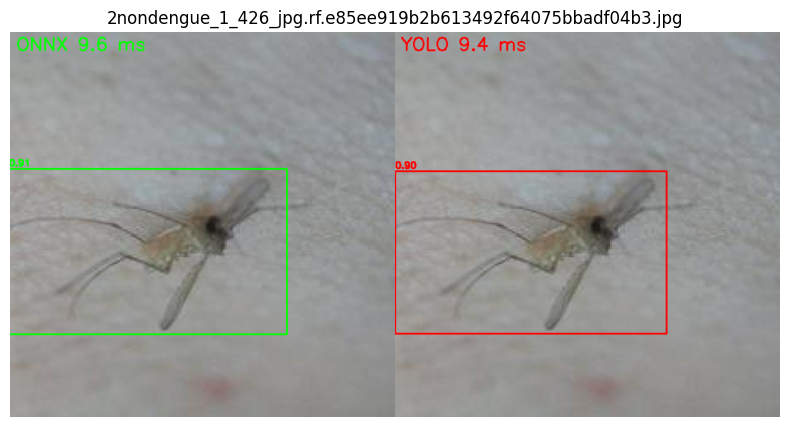

2nondengue_1_426_jpg.rf.e85ee919b2b613492f64075bbadf04b3.jpg
  ONNX  -> mean: 9.56 ms | median: 9.46 | std: 0.67 | det: 1
  YOLO  -> mean: 9.37 ms | median: 9.92 | std: 2.17 | det: 1



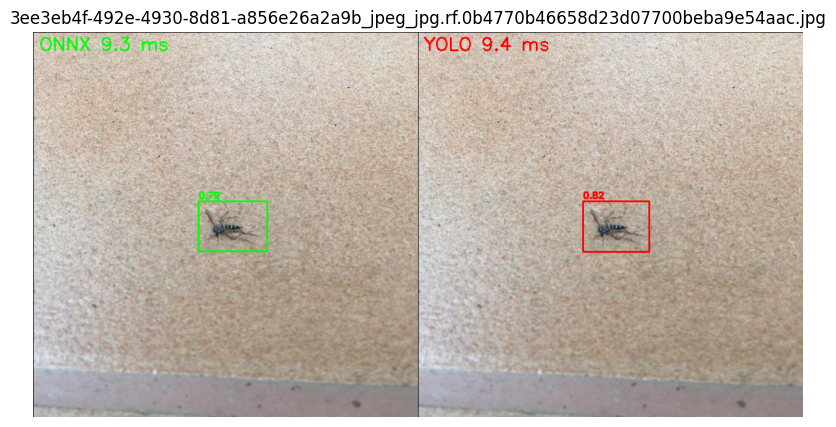

3ee3eb4f-492e-4930-8d81-a856e26a2a9b_jpeg_jpg.rf.0b4770b46658d23d07700beba9e54aac.jpg
  ONNX  -> mean: 9.28 ms | median: 9.14 | std: 0.36 | det: 1
  YOLO  -> mean: 9.35 ms | median: 9.21 | std: 1.21 | det: 1



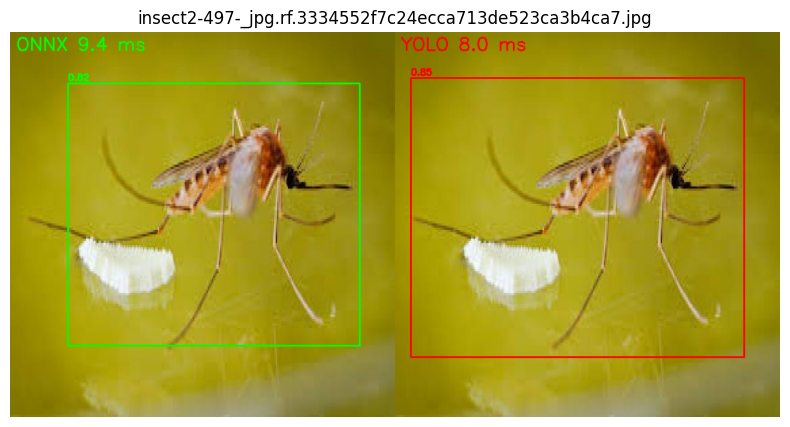

insect2-497-_jpg.rf.3334552f7c24ecca713de523ca3b4ca7.jpg
  ONNX  -> mean: 9.40 ms | median: 9.29 | std: 0.42 | det: 1
  YOLO  -> mean: 8.01 ms | median: 8.09 | std: 0.92 | det: 1



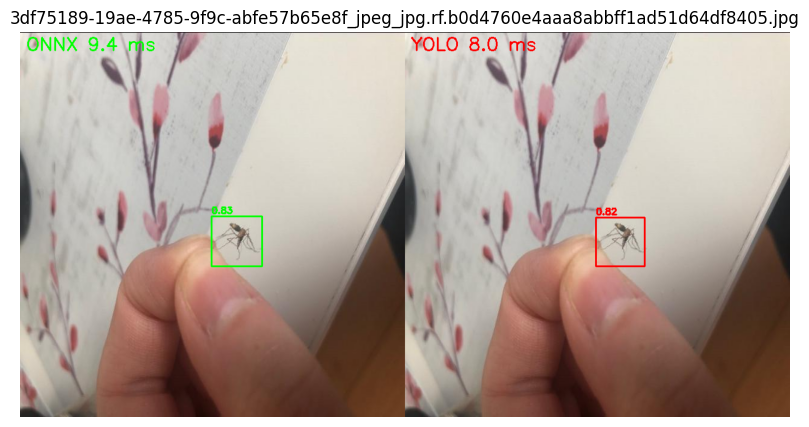

3df75189-19ae-4785-9f9c-abfe57b65e8f_jpeg_jpg.rf.b0d4760e4aaa8abbff1ad51d64df8405.jpg
  ONNX  -> mean: 9.37 ms | median: 9.33 | std: 0.43 | det: 1
  YOLO  -> mean: 8.01 ms | median: 8.02 | std: 0.67 | det: 1



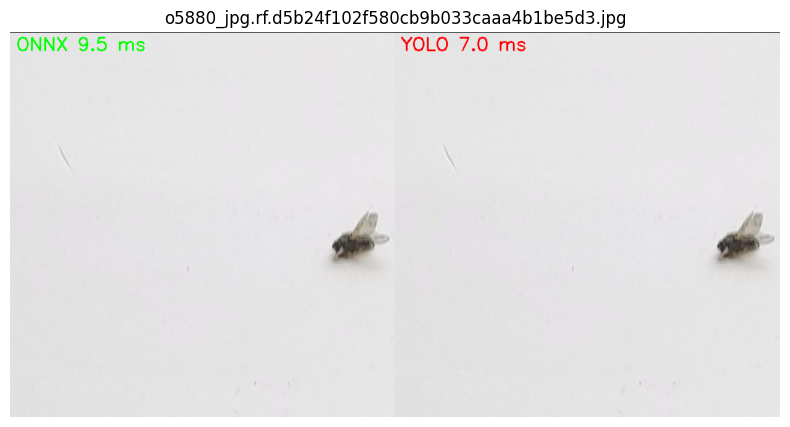

o5880_jpg.rf.d5b24f102f580cb9b033caaa4b1be5d3.jpg
  ONNX  -> mean: 9.50 ms | median: 9.59 | std: 0.46 | det: 0
  YOLO  -> mean: 7.00 ms | median: 6.85 | std: 0.93 | det: 0



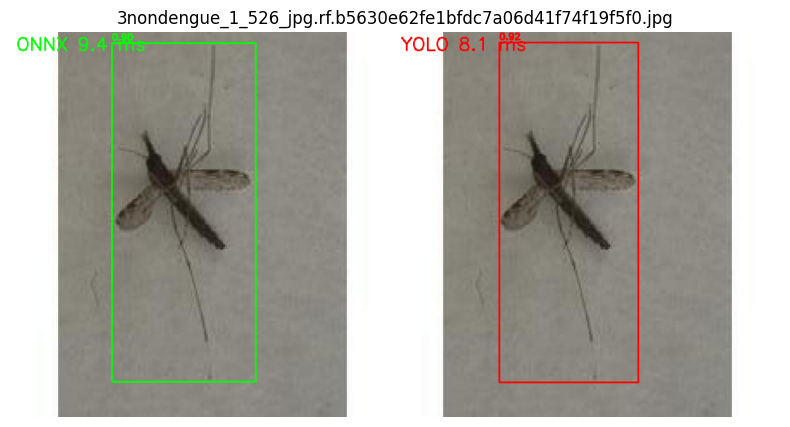

3nondengue_1_526_jpg.rf.b5630e62fe1bfdc7a06d41f74f19f5f0.jpg
  ONNX  -> mean: 9.35 ms | median: 9.22 | std: 0.41 | det: 1
  YOLO  -> mean: 8.09 ms | median: 7.75 | std: 1.28 | det: 1



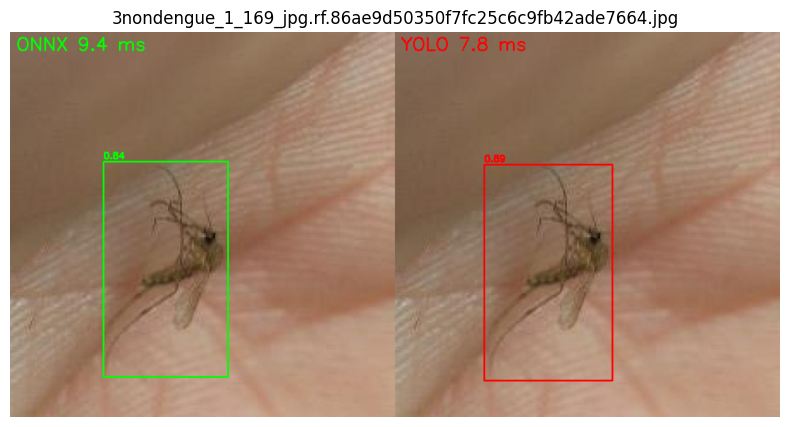

3nondengue_1_169_jpg.rf.86ae9d50350f7fc25c6c9fb42ade7664.jpg
  ONNX  -> mean: 9.43 ms | median: 9.40 | std: 0.45 | det: 1
  YOLO  -> mean: 7.77 ms | median: 7.97 | std: 0.65 | det: 1



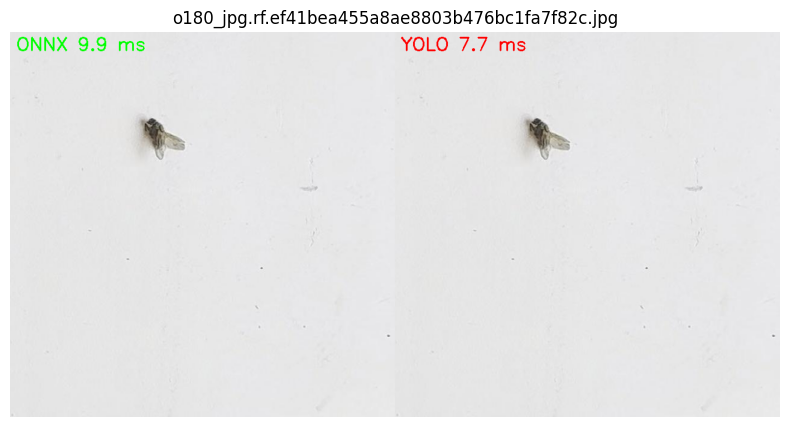

o180_jpg.rf.ef41bea455a8ae8803b476bc1fa7f82c.jpg
  ONNX  -> mean: 9.86 ms | median: 9.77 | std: 0.48 | det: 0
  YOLO  -> mean: 7.72 ms | median: 7.10 | std: 1.62 | det: 0



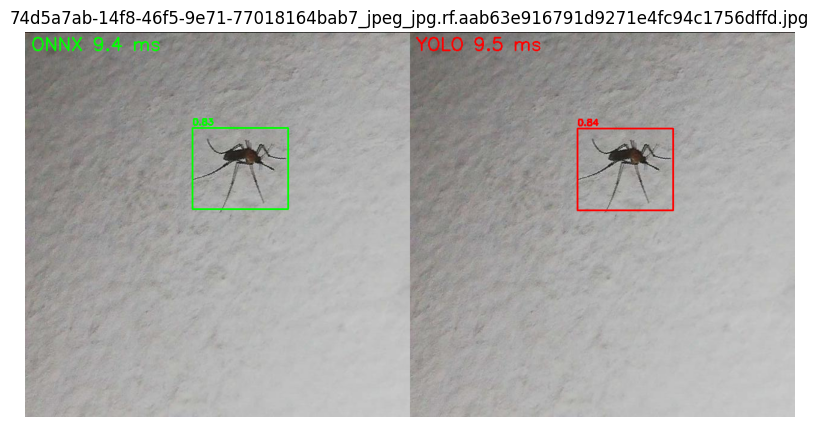

74d5a7ab-14f8-46f5-9e71-77018164bab7_jpeg_jpg.rf.aab63e916791d9271e4fc94c1756dffd.jpg
  ONNX  -> mean: 9.41 ms | median: 9.33 | std: 0.51 | det: 1
  YOLO  -> mean: 9.47 ms | median: 8.30 | std: 2.96 | det: 1



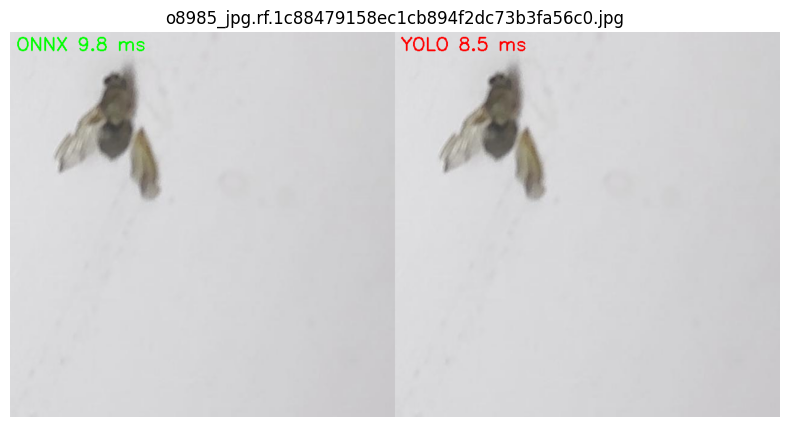

o8985_jpg.rf.1c88479158ec1cb894f2dc73b3fa56c0.jpg
  ONNX  -> mean: 9.76 ms | median: 9.68 | std: 0.56 | det: 0
  YOLO  -> mean: 8.53 ms | median: 8.08 | std: 1.11 | det: 0


===== FINAL SUMMARY =====
ONNX  -> mean: 9.49 ms | median: 9.44 | std: 0.51
YOLO  -> mean: 8.33 ms | median: 8.03 | std: 1.69


In [2]:
import cv2
import numpy as np
import onnxruntime as ort
import time
import torch
from ultralytics import YOLO
from pathlib import Path
import os
import random
import statistics
import matplotlib.pyplot as plt

# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

TEST_IMAGES_PATH = ROOT / "0_Datasets" / "Mosquitoes_dataset" / "test" / "images"

SAVE_DIR = ROOT / "1_YOLO" /"comparison_results"


# MODELS PATH
YOLO_PT_PATH   = ROOT / "Models" / "best.pt"
YOLO_ONNX_PATH = ROOT / "Models" / "best.onnx"

# =========================

# =========================
# CONFIG
# =========================
os.makedirs(SAVE_DIR, exist_ok=True)

IMGSZ = 256
N_RUNS = 30
WARMUP = 3

CONF_THRESH = 0.25
NMS_IOU_THRESH = 0.45

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_ONNX_GPU = False

# =========================
# PREPROCESS
# =========================
def letterbox(image, new_size=256):
    h, w = image.shape[:2]
    scale = min(new_size / w, new_size / h)
    nw, nh = int(w * scale), int(h * scale)

    img = cv2.resize(image, (nw, nh))
    new_img = np.full((new_size, new_size, 3), 114, dtype=np.uint8)

    top = (new_size - nh) // 2
    left = (new_size - nw) // 2
    new_img[top:top+nh, left:left+nw] = img

    return new_img, scale, left, top

def preprocess_onnx(frame):
    img, scale, px, py = letterbox(frame, IMGSZ)
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2,0,1))[None]
    return img, scale, px, py

# =========================
# NMS
# =========================
def nms(boxes, scores):
    if len(boxes) == 0:
        return []

    x1, y1, x2, y2 = boxes.T
    areas = (x2-x1)*(y2-y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2-xx1)
        h = np.maximum(0, yy2-yy1)

        iou = (w*h)/(areas[i]+areas[order[1:]]-w*h+1e-9)
        inds = np.where(iou <= NMS_IOU_THRESH)[0]
        order = order[inds+1]

    return keep

# =========================
# ONNX DECODE
# =========================
def decode(output, h, w, scale, px, py):
    out = output[0]

    if out.ndim == 3:
        out = out[0]

    if out.shape[0] < out.shape[1]:
        out = out.T

    x,y,w_,h_,scores = out[:,0],out[:,1],out[:,2],out[:,3],out[:,4]

    x1,y1,x2,y2 = x-w_/2,y-h_/2,x+w_/2,y+h_/2

    x1=(x1-px)/scale; x2=(x2-px)/scale
    y1=(y1-py)/scale; y2=(y2-py)/scale

    boxes = np.stack([x1,y1,x2,y2],axis=1)

    mask = scores > CONF_THRESH
    boxes, scores = boxes[mask], scores[mask]

    keep = nms(boxes, scores)

    return boxes[keep], scores[keep]

# =========================
# DRAW
# =========================
def draw_boxes(img, boxes, scores, color):
    for box, score in zip(boxes, scores):
        x1,y1,x2,y2 = map(int, box)
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        cv2.putText(img, f"{score:.2f}", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return img

# =========================
# LOAD MODELS
# =========================
print("\n===== DEVICE INFO =====")

yolo_model = YOLO(YOLO_PT_PATH)
yolo_model.to(DEVICE)

print(f"YOLO device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

providers = ['CPUExecutionProvider']
if USE_ONNX_GPU:
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']

onnx_session = ort.InferenceSession(YOLO_ONNX_PATH, providers=providers)
onnx_input = onnx_session.get_inputs()[0].name

print(f"ONNX providers: {onnx_session.get_providers()}")
print("========================\n")

# =========================
# TIMING FUNCTIONS
# =========================
def measure_yolo(img):
    times = []
    for i in range(WARMUP + N_RUNS):
        if DEVICE == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        _ = yolo_model(img, verbose=False)
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        if i >= WARMUP:
            times.append((t1 - t0) * 1000)
    return times

def measure_onnx(img):
    inp, _, _, _ = preprocess_onnx(img)
    times = []
    for i in range(WARMUP + N_RUNS):
        t0 = time.perf_counter()
        _ = onnx_session.run(None, {onnx_input: inp})
        t1 = time.perf_counter()

        if i >= WARMUP:
            times.append((t1 - t0) * 1000)
    return times

# =========================
# MAIN LOOP
# =========================
all_images = list(Path(TEST_IMAGES_PATH).glob("*.*"))
selected_images = random.sample(all_images, min(10, len(all_images)))

# Store global stats
all_yolo_times = []
all_onnx_times = []

for img_path in selected_images:
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]

    # -------- TIMING --------
    yolo_times = measure_yolo(img)
    onnx_times = measure_onnx(img)

    all_yolo_times.extend(yolo_times)
    all_onnx_times.extend(onnx_times)

    # -------- STATS --------
    yolo_mean = statistics.mean(yolo_times)
    yolo_median = statistics.median(yolo_times)
    yolo_std = statistics.stdev(yolo_times)

    onnx_mean = statistics.mean(onnx_times)
    onnx_median = statistics.median(onnx_times)
    onnx_std = statistics.stdev(onnx_times)

    # -------- VISUAL --------
    inp, scale, px, py = preprocess_onnx(img)
    out = onnx_session.run(None, {onnx_input: inp})
    onnx_boxes, onnx_scores = decode(out, h, w, scale, px, py)

    r = yolo_model(img, verbose=False)[0]
    if r.boxes is not None:
        yolo_boxes = r.boxes.xyxy.cpu().numpy()
        yolo_scores = r.boxes.conf.cpu().numpy()
    else:
        yolo_boxes, yolo_scores = [], []

    # Detection count
    n_onnx = len(onnx_boxes)
    n_yolo = len(yolo_boxes)

    # Draw
    img_onnx = draw_boxes(img.copy(), onnx_boxes, onnx_scores, (0,255,0))
    img_yolo = draw_boxes(img.copy(), yolo_boxes, yolo_scores, (0,0,255))

    combined = np.hstack([img_onnx, img_yolo])

    cv2.putText(combined, f"ONNX {onnx_mean:.1f} ms", (10,30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.putText(combined, f"YOLO {yolo_mean:.1f} ms", (w+10,30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

    # Save
    cv2.imwrite(os.path.join(SAVE_DIR, img_path.name), combined)

    # Show
    plt.figure(figsize=(10,5))
    plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

    # Terminal output (per image)
    print(f"{img_path.name}")
    print(f"  ONNX  -> mean: {onnx_mean:.2f} ms | median: {onnx_median:.2f} | std: {onnx_std:.2f} | det: {n_onnx}")
    print(f"  YOLO  -> mean: {yolo_mean:.2f} ms | median: {yolo_median:.2f} | std: {yolo_std:.2f} | det: {n_yolo}")
    print("")

# =========================
# FINAL GLOBAL SUMMARY
# =========================
print("\n===== FINAL SUMMARY =====")

print(f"ONNX  -> mean: {statistics.mean(all_onnx_times):.2f} ms | "
      f"median: {statistics.median(all_onnx_times):.2f} | "
      f"std: {statistics.stdev(all_onnx_times):.2f}")

print(f"YOLO  -> mean: {statistics.mean(all_yolo_times):.2f} ms | "
      f"median: {statistics.median(all_yolo_times):.2f} | "
      f"std: {statistics.stdev(all_yolo_times):.2f}")

print("==========================")

In [40]:
"""
evaluate_metrics_detection.py
==============================
Computes object detection metrics over the ENTIRE test dataset for:
  - ONNX  (CPU)
  - YOLO  (CPU)
  - YOLO  (GPU / CUDA) — skipped if no GPU is available

Output: table with Precision / Recall / F1 / mAP50 / mAP50-95 per backend,
        bar chart and PR curves saved to metrics_detection.png
"""

import os
import time
import statistics
from pathlib import Path

import cv2
import numpy as np
import torch
import onnxruntime as ort
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from ultralytics import YOLO


# =========================
# PATHS
# =========================
ROOT = Path.cwd().parent

DATA_YAML_PATH   = ROOT / "0_Datasets" / "Mosquitoes_dataset" / "data.yaml"
TEST_IMAGES_PATH = ROOT / "0_Datasets" / "Mosquitoes_dataset" / "test" / "images"

# MODEL PATHS
YOLO_PT_PATH   = ROOT / "Models" / "best.pt"
YOLO_ONNX_PATH = ROOT / "Models" / "best.onnx"


# =============================================================================
# CONFIG
# =============================================================================
IMGSZ          = 256
CONF_THRESH    = 0.25
NMS_IOU_THRESH = 0.45
IOU_THRESH     = 0.5   # IoU threshold to consider a detection as TP


# =============================================================================
# PREPROCESSING — letterbox + normalization
# =============================================================================
def letterbox(image, new_size=256):
    h, w = image.shape[:2]
    scale = min(new_size / w, new_size / h)
    nw, nh = int(w * scale), int(h * scale)
    img = cv2.resize(image, (nw, nh))
    new_img = np.full((new_size, new_size, 3), 114, dtype=np.uint8)
    top  = (new_size - nh) // 2
    left = (new_size - nw) // 2
    new_img[top:top + nh, left:left + nw] = img
    return new_img, scale, left, top


def preprocess(frame):
    img, scale, px, py = letterbox(frame, IMGSZ)
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))[None]
    return img, scale, px, py


# =============================================================================
# MANUAL NMS
# =============================================================================
def nms(boxes, scores):
    if len(boxes) == 0:
        return []
    x1, y1, x2, y2 = boxes.T
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    keep  = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w   = np.maximum(0, xx2 - xx1)
        h   = np.maximum(0, yy2 - yy1)
        iou = (w * h) / (areas[i] + areas[order[1:]] - w * h + 1e-9)
        order = order[np.where(iou <= NMS_IOU_THRESH)[0] + 1]
    return keep


# =============================================================================
# DECODE ONNX OUTPUT
# =============================================================================
def decode(output, h, w, scale, px, py):
    out = output[0]
    if out.ndim == 3:
        out = out[0]
    if out.shape[0] < out.shape[1]:
        out = out.T

    x, y, w_, h_, scores = out[:, 0], out[:, 1], out[:, 2], out[:, 3], out[:, 4]

    if np.max(w_) <= 2:
        x1 = (x - w_ / 2) * IMGSZ;  x2 = (x + w_ / 2) * IMGSZ
        y1 = (y - h_ / 2) * IMGSZ;  y2 = (y + h_ / 2) * IMGSZ
    else:
        x1, y1, x2, y2 = x - w_ / 2, y - h_ / 2, x + w_ / 2, y + h_ / 2

    x1 = (x1 - px) / scale;  x2 = (x2 - px) / scale
    y1 = (y1 - py) / scale;  y2 = (y2 - py) / scale

    boxes  = np.stack([x1, y1, x2, y2], axis=1)
    mask   = scores > CONF_THRESH
    boxes, scores = boxes[mask], scores[mask]
    keep   = nms(boxes, scores)
    return boxes[keep], scores[keep] if len(keep) else (boxes[keep], scores[keep])


# =============================================================================
# IoU BETWEEN TWO BOXES
# =============================================================================
def iou_box(a, b):
    x1 = max(a[0], b[0]);  y1 = max(a[1], b[1])
    x2 = min(a[2], b[2]);  y2 = min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    return inter / (
        (a[2] - a[0]) * (a[3] - a[1]) +
        (b[2] - b[0]) * (b[3] - b[1]) -
        inter + 1e-9
    )


# =============================================================================
# GROUND TRUTH LOADING — YOLO format (.txt)
# =============================================================================
def load_gt(img_path: Path, img_w: int, img_h: int) -> list:
    label_path = str(img_path).replace("images", "labels")
    for ext in [".txt"]:
        lp = Path(label_path).with_suffix(ext)
        if lp.exists():
            gt = []
            for line in open(lp):
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, x, y, bw, bh = map(float, parts[:5])
                gt.append([
                    (x - bw / 2) * img_w, (y - bh / 2) * img_h,
                    (x + bw / 2) * img_w, (y + bh / 2) * img_h,
                ])
            return gt
    return []


# =============================================================================
# TP / FP / FN COMPUTATION PER IMAGE
# =============================================================================
def match_predictions(pred_boxes, gt_boxes):
    """Returns (TP, FP, FN) for a single image."""
    TP = 0
    matched = set()
    for pb in pred_boxes:
        ok = False
        for i, gb in enumerate(gt_boxes):
            if i in matched:
                continue
            if iou_box(pb, gb) > IOU_THRESH:
                TP += 1
                matched.add(i)
                ok = True
                break
        if not ok:
            pass   # FP counted below
    FP = len(pred_boxes) - TP
    FN = len(gt_boxes)   - TP
    return TP, FP, FN


# =============================================================================
# AP COMPUTATION (area under PR curve) with 101-point interpolation
# =============================================================================
def compute_ap(precisions, recalls):
    """AP using 101-point interpolation (COCO-style)."""
    ap = 0.0
    for t in np.linspace(0, 1, 101):
        p = precisions[recalls >= t]
        ap += np.max(p) if len(p) else 0.0
    return ap / 101


# =============================================================================
# ONNX METRICS — manual inference
# =============================================================================
def onnx_metrics():
    print("  [ONNX CPU] evaluating dataset...")
    session    = ort.InferenceSession(YOLO_ONNX_PATH, providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name

    # warmup
    dummy = np.zeros((1, 3, IMGSZ, IMGSZ), np.float32)
    session.run(None, {input_name: dummy})

    all_TP = all_FP = all_FN = 0
    # accumulate scores and TP flags per detection for PR curve
    all_scores, all_tp_flags = [], []
    total_gt = 0

    img_paths = sorted(Path(TEST_IMAGES_PATH).glob("*.*"))
    n = len(img_paths)

    for idx, img_path in enumerate(img_paths, 1):
        if idx % max(1, n // 10) == 0 or idx == n:
            print(f"    [{idx:>{len(str(n))}}/{n}]  {img_path.name}")

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        gt   = load_gt(img_path, w, h)
        total_gt += len(gt)

        inp, scale, px, py = preprocess(img)
        out = session.run(None, {input_name: inp})

        result = decode(out, h, w, scale, px, py)
        # decode returns (boxes, scores)
        if isinstance(result, tuple):
            pred_boxes, pred_scores = result
        else:
            pred_boxes = result
            pred_scores = np.ones(len(pred_boxes))

        TP, FP, FN = match_predictions(pred_boxes, gt)
        all_TP += TP; all_FP += FP; all_FN += FN

        matched = set()
        for pb, sc in zip(pred_boxes, pred_scores):
            hit = False
            for i, gb in enumerate(gt):
                if i in matched:
                    continue
                if iou_box(pb, gb) > IOU_THRESH:
                    matched.add(i); hit = True; break
            all_scores.append(float(sc))
            all_tp_flags.append(1 if hit else 0)

    precision = all_TP / (all_TP + all_FP + 1e-9)
    recall    = all_TP / (all_TP + all_FN + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    # PR Curve
    order     = np.argsort(-np.array(all_scores))
    tp_cum    = np.cumsum(np.array(all_tp_flags)[order])
    fp_cum    = np.cumsum(1 - np.array(all_tp_flags)[order])
    rec_curve = tp_cum / (total_gt + 1e-9)
    pre_curve = tp_cum / (tp_cum + fp_cum + 1e-9)
    ap50      = compute_ap(pre_curve, rec_curve)

    return {
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "map50":     ap50,
        "map50_95":  None,           # not available without multi-scale
        "pr_rec":    rec_curve,
        "pr_pre":    pre_curve,
        "TP": all_TP, "FP": all_FP, "FN": all_FN,
    }


# =============================================================================
# YOLO METRICS — using model.val()
# =============================================================================
def yolo_metrics(device: str = "cpu"):
    label = "YOLO GPU" if device != "cpu" else "YOLO CPU"
    print(f"  [{label}] running model.val()...")
    model   = YOLO(YOLO_PT_PATH)
    metrics = model.val(data=DATA_YAML_PATH, split="test", imgsz=IMGSZ,
                        device=device, verbose=False)

    mp      = float(metrics.box.mp)
    mr      = float(metrics.box.mr)
    f1      = 2 * mp * mr / (mp + mr + 1e-9)
    map50   = float(metrics.box.map50)
    map5095 = float(metrics.box.map)

    # PR curves from metrics object (if available)
    try:
        pr_rec = metrics.box.r_curve.mean(axis=0)   # (N,)
        pr_pre = metrics.box.p_curve.mean(axis=0)
    except Exception:
        pr_rec = np.array([0.0, 1.0])
        pr_pre = np.array([mp, mp])

    return {
        "precision": mp,
        "recall":    mr,
        "f1":        f1,
        "map50":     map50,
        "map50_95":  map5095,
        "pr_rec":    pr_rec,
        "pr_pre":    pr_pre,
        "TP": None, "FP": None, "FN": None,
    }


# =============================================================================
# PRINT METRICS
# =============================================================================
def print_metrics(label: str, m: dict):
    print(f"\n  {'─' * 52}")
    print(f"  Backend : {label}")
    print(f"  {'─' * 52}")
    print(f"  Precision : {m['precision']:.4f}")
    print(f"  Recall    : {m['recall']:.4f}")
    print(f"  F1-Score  : {m['f1']:.4f}")
    print(f"  mAP@0.50  : {m['map50']:.4f}")
    if m["map50_95"] is not None:
        print(f"  mAP@.5:.95: {m['map50_95']:.4f}")
    if m["TP"] is not None:
        print(f"  TP={m['TP']}  FP={m['FP']}  FN={m['FN']}")


# =============================================================================
# SUMMARY TABLE
# =============================================================================
def print_summary_table(results: dict):
    cols = ["Precision", "Recall", "F1", "mAP50", "mAP50-95"]
    keys = ["precision", "recall", "f1", "map50", "map50_95"]
    header = f"  {'Backend':<22}" + "".join(f"{c:>13}" for c in cols)
    sep    = "=" * len(header)
    print(f"\n{sep}")
    print("COMPARATIVE SUMMARY")
    print(sep)
    print(header)
    print("  " + "─" * (len(header) - 2))
    for backend, m in results.items():
        row = f"  {backend:<22}"
        for k in keys:
            val = m[k]
            row += f"{'N/A':>13}" if val is None else f"{val:>13.4f}"
        print(row)
    print(sep)


# =============================================================================
# PLOT: metric bar charts + PR curves
# =============================================================================
def plot_results(results: dict, save_path: str = "metrics_detection.png"):
    backends        = list(results.keys())
    colors          = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
    metrics_to_plot = ["precision", "recall", "f1", "map50"]
    labels_plot     = ["Precision", "Recall", "F1-Score", "mAP@50"]

    fig = plt.figure(figsize=(14, 9))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Bar charts per metric ─────────────────────────────────────────────────
    positions = [(0, 0), (0, 1), (1, 0)]
    for pos, key, lbl in zip(positions, metrics_to_plot[:3], labels_plot[:3]):
        ax = fig.add_subplot(gs[pos[0], pos[1]])
        vals = [results[b][key] if results[b][key] is not None else 0
                for b in backends]
        bars = ax.bar(backends, vals, color=colors[:len(backends)], width=0.5)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(lbl)
        ax.set_title(lbl, fontweight="bold")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=9)
        ax.tick_params(axis="x", labelsize=8)

    # ── Overlapping PR curves ─────────────────────────────────────────────────
    ax_pr = fig.add_subplot(gs[1, 1])
    for (backend, m), color in zip(results.items(), colors):
        rec = m["pr_rec"]
        pre = m["pr_pre"]
        if rec is not None and pre is not None and len(rec) > 1:
            # ensure ascending recall order
            order = np.argsort(rec)
            ax_pr.plot(rec[order], pre[order], lw=2, color=color,
                       label=f"{backend}  (mAP50={m['map50']:.4f})")

    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title("Precision-Recall Curves", fontweight="bold")
    ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.05)
    ax_pr.legend(loc="lower left", fontsize=8)
    ax_pr.grid(linestyle="--", alpha=0.4)

    fig.suptitle(
        "Object Detection Metrics — YOLOv8 / ONNX\n"
        f"Dataset: {TEST_IMAGES_PATH}  |  IoU threshold: {IOU_THRESH}  |  Conf: {CONF_THRESH}",
        fontsize=11, fontweight="bold"
    )

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\nChart saved to: {save_path}")
    plt.show()


# =============================================================================
# MAIN
# =============================================================================
def evaluate():
    has_cuda = torch.cuda.is_available()
    gpu_name = torch.cuda.get_device_name(0) if has_cuda else "—"
    print(f"CUDA available: {has_cuda}" + (f"  ({gpu_name})" if has_cuda else ""))
    print(f"Configuration: CONF={CONF_THRESH}, NMS_IOU={NMS_IOU_THRESH}, "
          f"IOU_THRESH={IOU_THRESH}, IMGSZ={IMGSZ}\n")

    results = {}

    # ── ONNX CPU ──────────────────────────────────────────────────────────────
    results["ONNX (CPU)"] = onnx_metrics()
    print_metrics("ONNX (CPU)", results["ONNX (CPU)"])

    # ── YOLO CPU ──────────────────────────────────────────────────────────────
    results["YOLO (CPU)"] = yolo_metrics(device="cpu")
    print_metrics("YOLO (CPU)", results["YOLO (CPU)"])

    # ── YOLO GPU ──────────────────────────────────────────────────────────────
    if has_cuda:
        results["YOLO (GPU)"] = yolo_metrics(device=0)
        print_metrics("YOLO (GPU)", results["YOLO (GPU)"])

    # ── Summary table and chart ───────────────────────────────────────────────
    print_summary_table(results)
    plot_results(results)


if __name__ == "__main__":
    evaluate()

CUDA available: True  (NVIDIA GeForce RTX 5060 Laptop GPU)
Configuration: CONF=0.25, NMS_IOU=0.45, IOU_THRESH=0.5, IMGSZ=256

  [ONNX CPU] evaluating dataset...
    [ 137/1379]  23ec2c43-b1fd-4377-83bf-97f401500df5_jpeg_jpg.rf.f9d840d9079aee2c12476b9306a14316.jpg
    [ 274/1379]  3a5eade3-c4d2-4e44-a94d-8bf3dd376e8f_jpeg_jpg.rf.d554dd82ee9e1e092577dc8bf89c4ab2.jpg
    [ 411/1379]  3nondengue_1_70_jpg.rf.d7fc202719592ec4af9fd8e35f8de382.jpg
    [ 548/1379]  4d60a352-7204-4be7-a35e-4c857747c55d_jpeg_jpg.rf.f9e4f88496926b98c1066ebc776e24fb.jpg
    [ 685/1379]  5cf73413-0072-4c2e-8d04-2480919a8d64_jpeg_jpg.rf.fd2dedec2fbee1350575b8c2e5104f2a.jpg
    [ 822/1379]  9e0659f8-22a5-405d-b679-eeeb8c3b3e0d_jpeg_jpg.rf.04fe7f250fb6959b2f4f9e39c83fc388.jpg
    [ 959/1379]  fram2955_jpg.rf.1f5c47955040e63301835cc7c268f9d2.jpg
    [1096/1379]  o15570_jpg.rf.86725fb15926e8976ad330dffb15010f.jpg
    [1233/1379]  o38145_jpg.rf.c4471ca701279083d51c27176a038b9a.jpg
    [1370/1379]  photo_17_2025-06-04_22-3

<Figure size 1400x900 with 4 Axes>